<a href="https://colab.research.google.com/github/Wezz-git/AI-samples/blob/main/Classical_Risk_Modeling_(GARCH).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Focus: Model Interpretability and Risk Measurement.

Project: Volatility (Risk) Forecasting with GARCH(1,1).

Goal: Build the classical econometric model for forecasting future volatility based on the principle of volatility clustering (risk follows risk). This model is fully interpretable, which is critical for auditability.

Skill: Understanding Heteroskedasticity (non-constant variance) and using the arch library to model the variance of returns.

In [3]:
!pip install arch
!pip install yfinance
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

# Get the data of $SPY
ticker = 'SPY'

# Need years of data for reliable risk modeling
data = yf.download(ticker, start='2010-01-01', end='2023-12-31')

# Calculate Log Returns (daily) - Standard for volatility models
# Multiply by 100 - ARCH library uses larger numbers for stability
# 'Close' = represents the final, consensus price of the asset at the end of the trading day. Robust for risk modeling

data['Log_Returns'] = np.log(data['Close'] / data['Close'].shift(1)) * 100
# GARCH models predict volatility based on returns, which are derived from closing prices.

# Drop first row ( Which is NaN due to shift(1))
df_returns = data['Log_Returns'].dropna()

print(df_returns.head())
print(df_returns.tail())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 22.7 MB/s eta 0:00:00


/tmp/ipython-input-2485560853.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2010-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed

Date
2010-01-05    0.264355
2010-01-06    0.070394
2010-01-07    0.421262
2010-01-08    0.332161
2010-01-11    0.139584
Name: Log_Returns, dtype: float64
Date
2023-12-22    0.200756
2023-12-26    0.421371
2023-12-27    0.180643
2023-12-28    0.037761
2023-12-29   -0.289914
Name: Log_Returns, dtype: float64


**Build and Fit GANCH Model**

1 - The model looks at yesterday's surprise (p=1) to predict today's risk.

2 - The model looks at yesterday's risk level (q=1) to predict today's risk.

In [4]:
# Initial GARCH(1,1) model
# Specify vol='Garch' and p=1, q=1
# mean='Zero' = so returns average close to zero over long periods

model = arch_model(df_returns, mean='Zero', vol='Garch', p=1, q=1)

# Fit the model
# fit() - performs optimization
results = model.fit(disp='off')     # disp='off' keeps training output clean

# Print the summary
print("\n--- GARCH(1,1) Model Summary ---")
print(results.summary())


--- GARCH(1,1) Model Summary ---
                       Zero Mean - GARCH Model Results                        
Dep. Variable:            Log_Returns   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4546.66
Distribution:                  Normal   AIC:                           9099.33
Method:            Maximum Likelihood   BIC:                           9117.82
                                        No. Observations:                 3521
Date:                Tue, Nov 25 2025   Df Residuals:                     3521
Time:                        10:55:32   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0352  7

OMEGA (ω)	0.0352 - The Long-Run Average Volatility:

This is the minimum, baseline level of risk that exists even when the market is perfectly calm.


ALPHA (α₁)	0.1625 - The impact of Shocks (News/Surprises):

When the market is hit by a surprise (a large positive or negative return), that shock contributes 16.25% to increasing risk the next day.


BETA (β₁)	0.8077 - The impact of Yesterday's Risk Level (Clustering):

80.77% of yesterday's high risk level persists and carries over to influence today's risk. This proves volatility clustering is very strong.

(The $\alpha + \beta$ Test) - The most important part of the analysis is the sum of Alpha + Beta:$$\alpha_1 + \beta_1 = 0.1625 + 0.8077 = 0.9702$$

The Interpretation: Since the sum (0.9702) is very close to $1.0$ (typically anything above $0.90$ is high), it proves that the GARCH model fits the financial data very well. It tells the risk team: "When volatility hits, it stays high and fades away very slowly."

**Validating the results**

/tmp/ipython-input-2905753501.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2010-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed


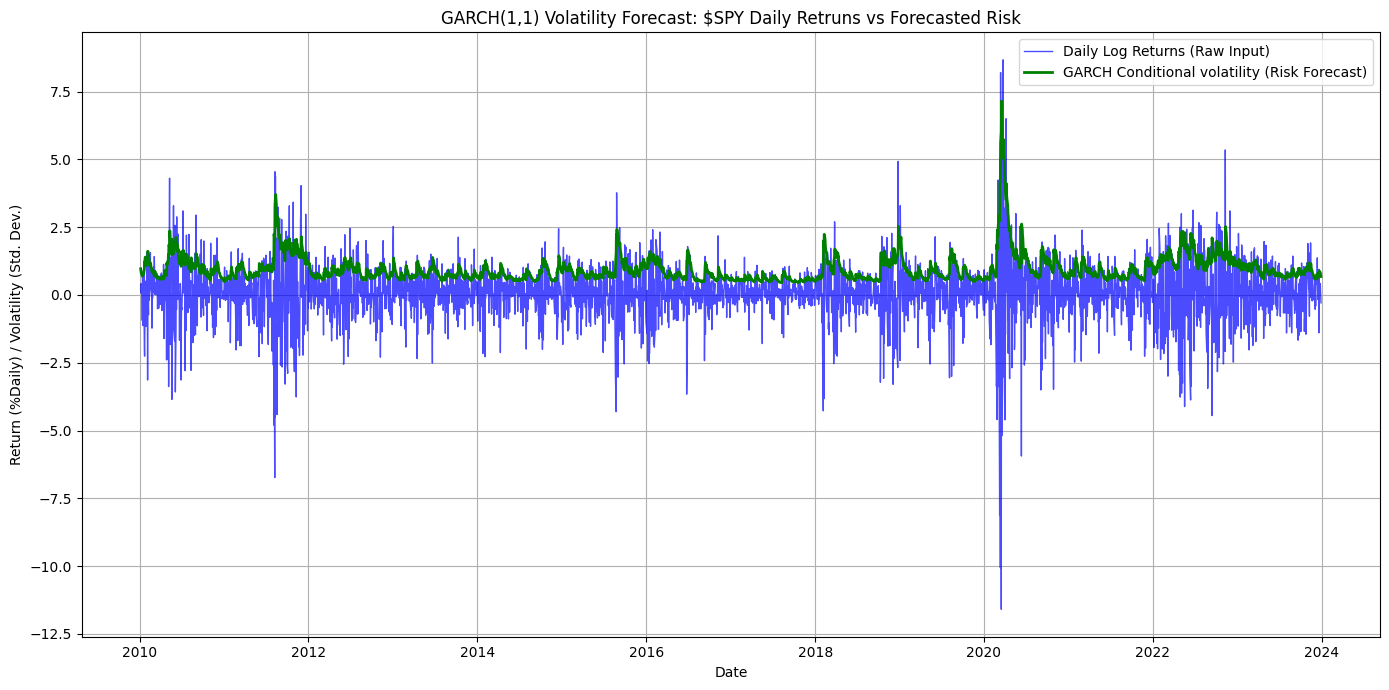

In [8]:
# get previous data prep

ticker = 'SPY'
data = yf.download(ticker, start='2010-01-01', end='2023-12-31')
data['Log_Returns'] = np.log(data['Close'] / data['Close'].shift(1)) * 100
df_returns = data['Log_Returns'].dropna()

# fit the model again to ensure conditional volatility data
model = arch_model(df_returns, mean='Zero', vol='Garch', p=1, q=1)
results = model.fit(disp='off')

# Extract conditional volatility (GARCH forecast) - GARCH model's single most important output: it is the forecast of risk.
conditional_volatility = results.conditional_volatility

# Plotting raw returns and forecasred volatility
plt.figure(figsize=(14, 7))

# 1 - Plot raw returns (Input)
plt.plot(df_returns.index, df_returns,
         label='Daily Log Returns (Raw Input)', alpha=0.7, color='blue', linewidth=1)
# 2 - Plot raw returns (Output/Risk Forecast)
plt.plot(conditional_volatility.index, conditional_volatility,
         label='GARCH Conditional volatility (Risk Forecast)', color='green', linewidth=2)

plt.title('GARCH(1,1) Volatility Forecast: $SPY Daily Retruns vs Forecasted Risk')
plt.xlabel('Date')
plt.ylabel('Return (%Daily) / Volatility (Std. Dev.)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('garch_volatility_plot.png')

GARCH Volatility Forecast is Valid